# (01) Cadena: fit P-VAE (final)

device = ```cuda:0```

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from mcfe.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def process_and_plot_results():
    eval_results = normative_modules.run_eval(readout_model, val_dl)
    fev, var_explained, explainable_var, mse, total_variance = eval_results
    fev_mean = torch.nanmean(fev).item()
    fev_all = torch.nan_to_num(fev.detach().cpu(), nan=0.0).clip(min=0)

    print('Held-out FEV mean:', fev_mean)

    plt.figure(figsize=(8, 3))
    plt.plot(fev_all)
    plt.title(f'Per-neuron FEV (mean={fev_mean:.3f},  median={np.nanmedian(fev_all):0.3f})')
    plt.xlabel('Neuron')
    plt.ylabel('FEV')
    plt.tight_layout()
    plt.show()
    
    fig, ax = create_figure(1, 1, (3.5, 2))
    sns.histplot(fev_all, ax=ax)
    plt.show()
    
    return fev_all

In [3]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

In [4]:
from mcfe.main.load_model import load_model
from mcfe.common.helpers import print_num_params

## prepare cadena data

In [5]:
import importlib

spec = importlib.util.spec_from_file_location(
    'normative_modules', '/home/hadi/Dropbox/git/_CadenaV1/normative.py')
normative_modules = importlib.util.module_from_spec(spec)
sys.modules['normative_modules'] = normative_modules
spec.loader.exec_module(normative_modules)

In [6]:
train_ds_raw, val_ds_raw = normative_modules.get_train_val_datasets()

num_neurons = train_ds_raw[0]['robs'].shape[0]
print(f"num_neurons = {num_neurons}")

num_neurons = 166

## prepare fits / wandb

In [7]:
chkpts_dir = add_home('Dropbox/chkpts/MCFE')

TAG = 'rebuttal_imagenet40'

fits = [
    f for f in sorted(os.listdir(chkpts_dir), key=alphanum_sort_key)
    if all(e in f for e in ['pois', TAG])
]

print(len(fits))
print(fits)

23

[
    'pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,14:03)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,17:03)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_yoru-0_(2026_03_30,16:09)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_yoru-0_(2026_03_30,17:27)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_yoru-0_(2026_03_30,18:43)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0_(2026_03_30,14:20)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0_(2026_03_30,16:36)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,17:18)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,18:27)',
    'pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_yoru-0_(2026_03_30,14:57)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,13:32)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,14:55)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,15:18)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,16:20)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,16:30)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0_(2026_03_30,13:25)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0_(2026_03_30,14:43)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0_(2026_03_30,15:51)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0_(2026_03_30,16:54)',
    'pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_mach-0_(2026_03_30,13:23)',
    'pois_ImageNet40_beta(1)_kms-(128,10,3)_recon-exact_rebuttal_imagenet40_mach-0_(2026_03_30,13:28)',
    'pois_ImageNet40_beta(1)_kms-(128,11,3)_recon-exact_rebuttal_imagenet40_yoru-0_(2026_03_30,12:32)',
    'pois_ImageNet40_beta(1)_kms-(128,11,3)_recon-exact_rebuttal_imagenet40_yoru-0_(2026_03_30,13:04)'
]

In [8]:
api = wandb.Api()

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


## loop

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(
2026_03_30,14:03)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,14:03).pt

Held-out FEV mean: 0.33421531319618225

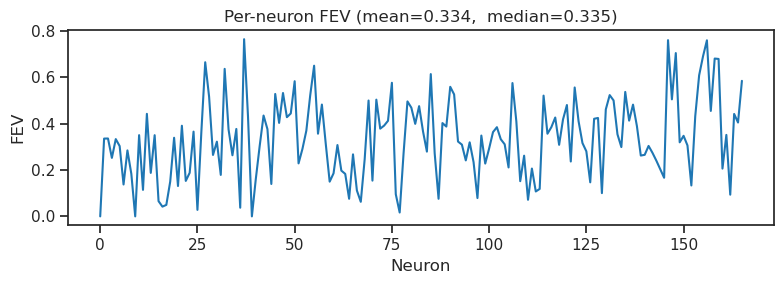

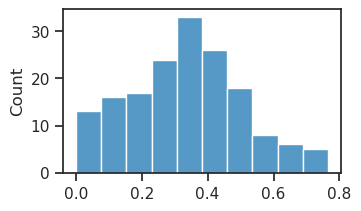

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0_(
2026_03_30,17:03)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,17:03).pt

Held-out FEV mean: 0.3288803696632385

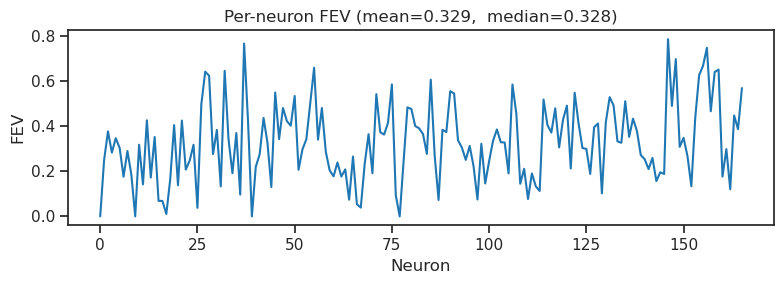

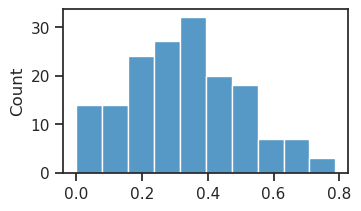

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_yoru-0_(
2026_03_30,16:09)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,16:09).pt

Held-out FEV mean: 0.32352444529533386

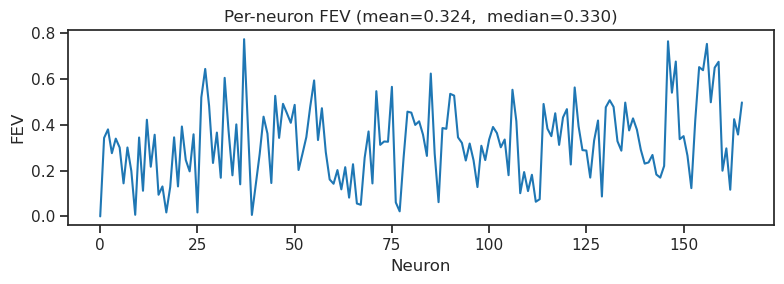

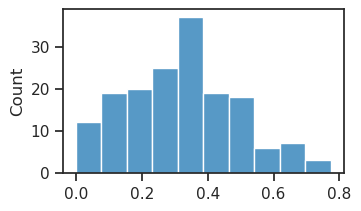

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_yoru-0_(
2026_03_30,17:27)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,17:27).pt

Held-out FEV mean: 0.3271746337413788

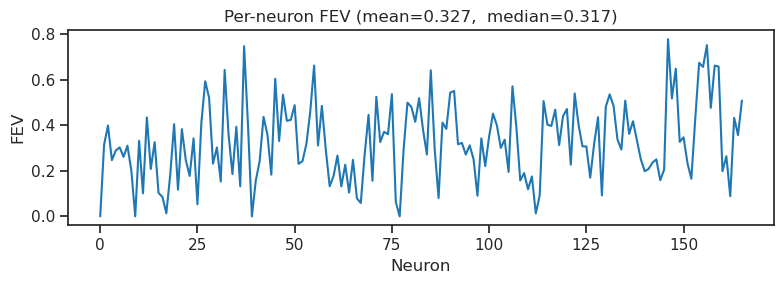

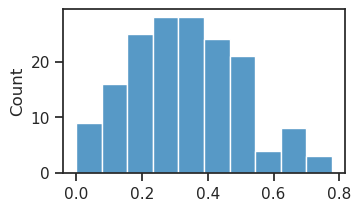

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_yoru-0_(
2026_03_30,18:43)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,18:43).pt

Held-out FEV mean: 0.3312537968158722

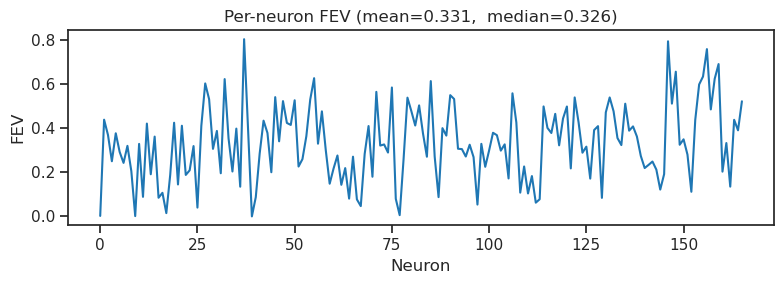

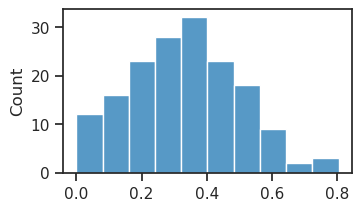

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0
_(2026_03_30,14:20)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,14:20).pt

Held-out FEV mean: 0.18919190764427185

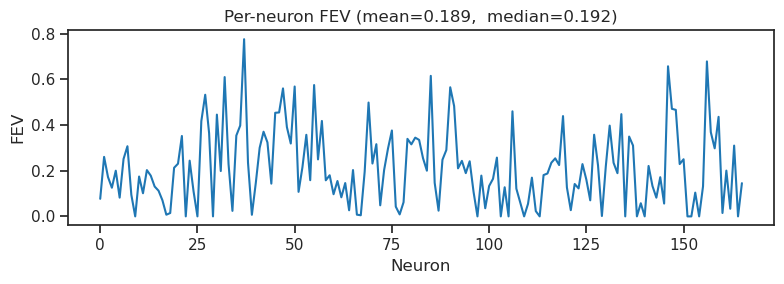

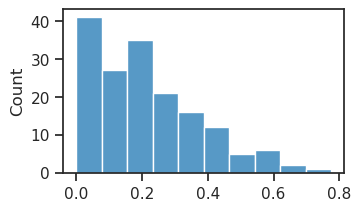

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie-0
_(2026_03_30,16:36)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,16:36).pt

Held-out FEV mean: 0.20806682109832764

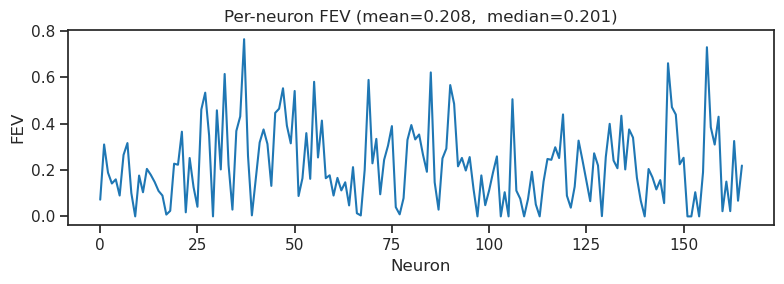

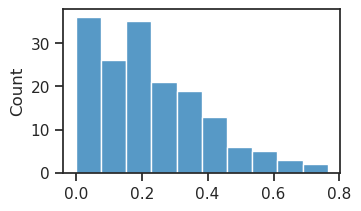

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_mach-0_(
2026_03_30,17:18)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,17:18).pt

Held-out FEV mean: 0.20890739560127258

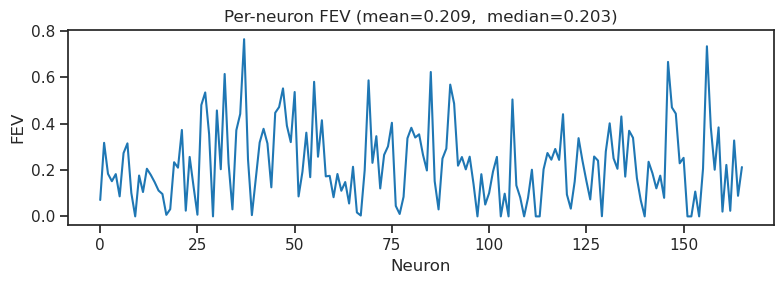

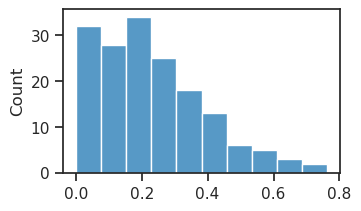

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_mach-0_(
2026_03_30,18:27)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,18:27).pt

Held-out FEV mean: 0.16933056712150574

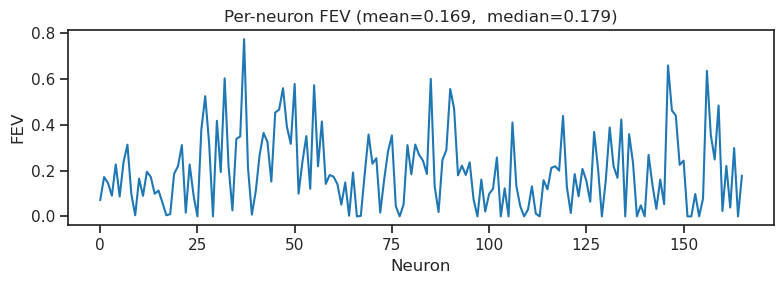

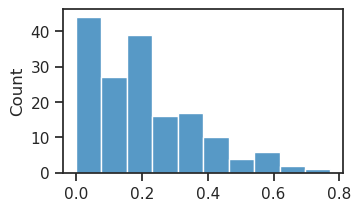

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-cubic_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_yoru-0_(
2026_03_30,14:57)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,14:57).pt

Held-out FEV mean: 0.19256874918937683

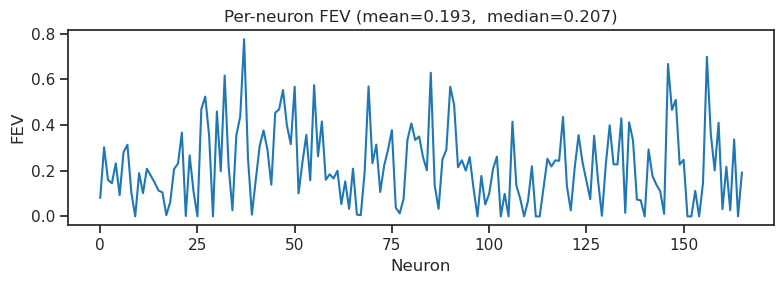

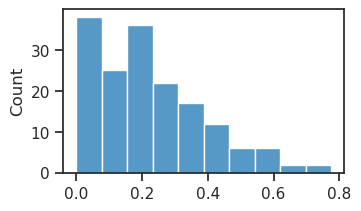

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0
_(2026_03_30,13:32)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,13:32).pt

Held-out FEV mean: 0.3464968502521515

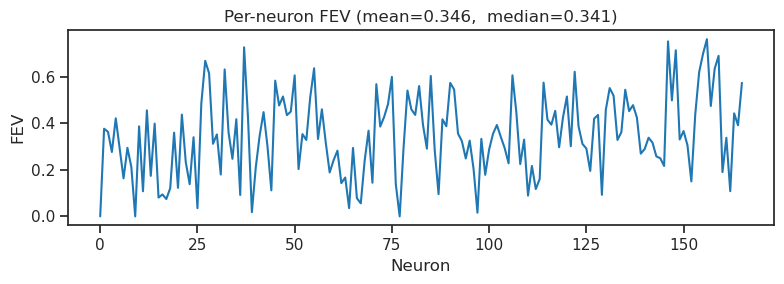

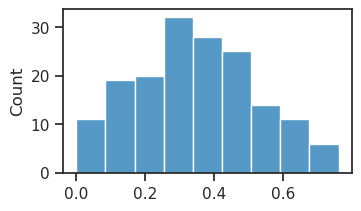

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0
_(2026_03_30,14:55)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,14:55).pt

Held-out FEV mean: 0.3359331786632538

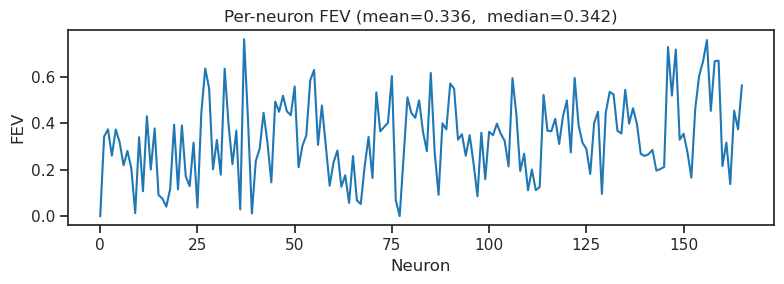

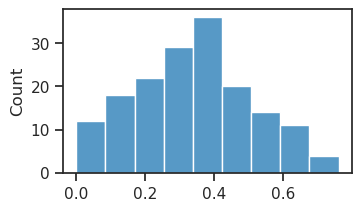

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0
_(2026_03_30,15:18)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,15:18).pt

Held-out FEV mean: 0.32582154870033264

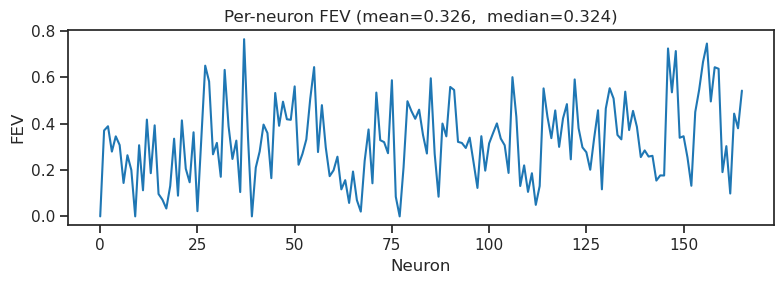

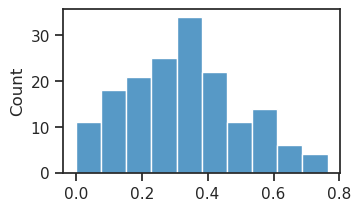

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0
_(2026_03_30,16:20)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,16:20).pt

Held-out FEV mean: 0.3257848918437958

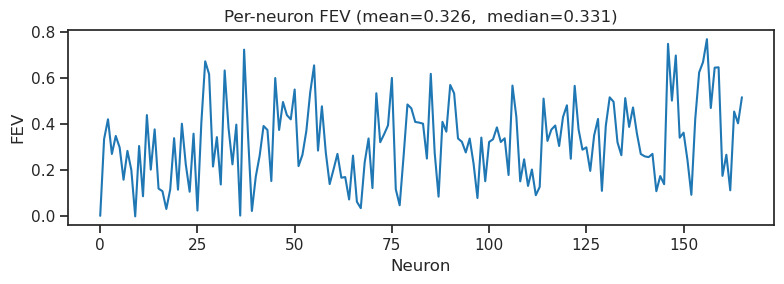

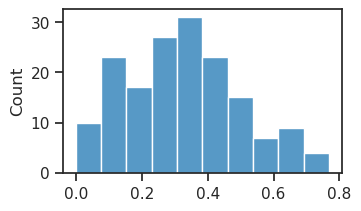

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,10,3)_recon-prob_rebuttal_imagenet40_mach-0
_(2026_03_30,16:30)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,16:30).pt

Held-out FEV mean: 0.32736796140670776

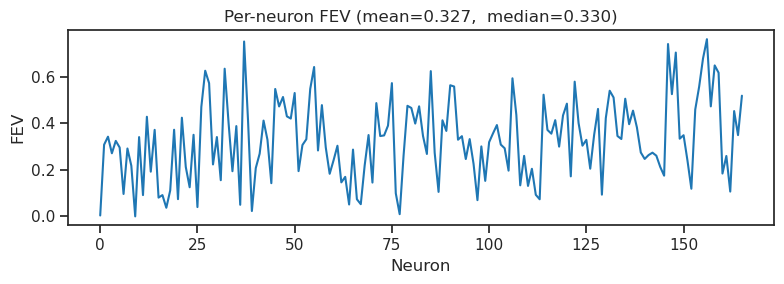

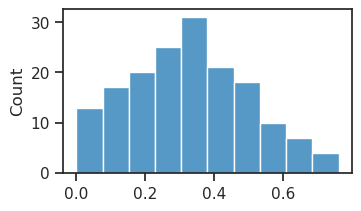

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie
-0_(2026_03_30,13:25)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,13:24).pt

Held-out FEV mean: 0.21697786450386047

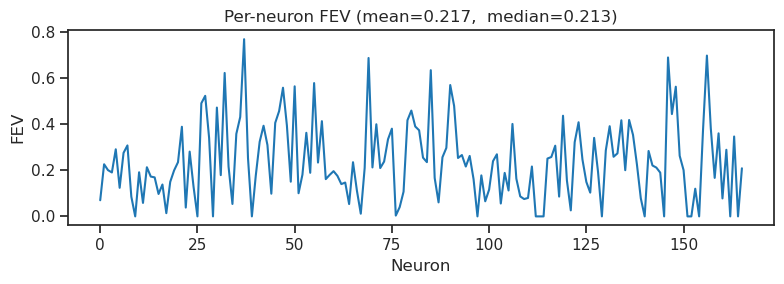

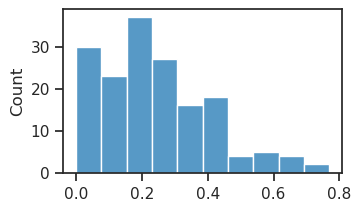

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie
-0_(2026_03_30,14:43)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,14:43).pt

Held-out FEV mean: 0.2202206403017044

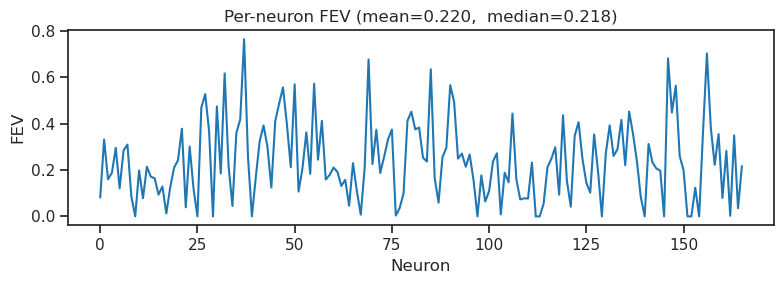

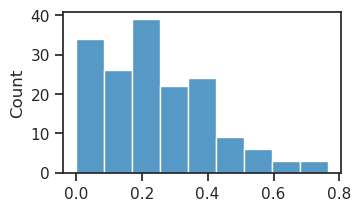

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie
-0_(2026_03_30,15:51)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,15:51).pt

Held-out FEV mean: 0.2113925814628601

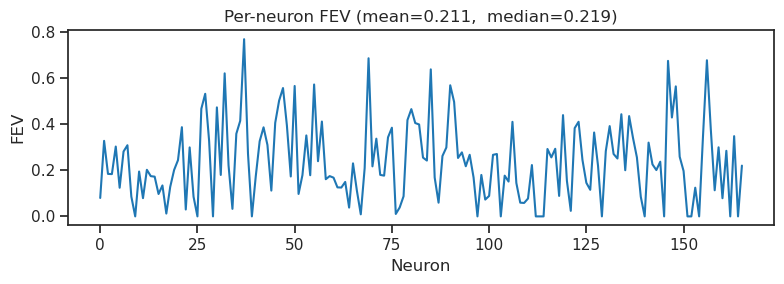

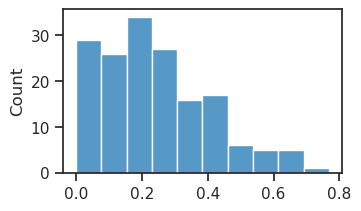

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_chewie
-0_(2026_03_30,16:54)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,16:54).pt

Held-out FEV mean: 0.21192529797554016

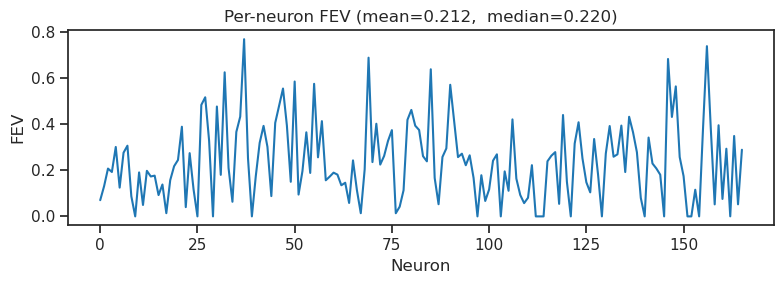

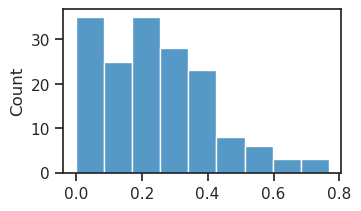

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois-sigmoid_ImageNet40_beta(1)_kms-(128,11,3)_recon-prob_rebuttal_imagenet40_mach-0
_(2026_03_30,13:23)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,13:23).pt

Held-out FEV mean: 0.24136145412921906

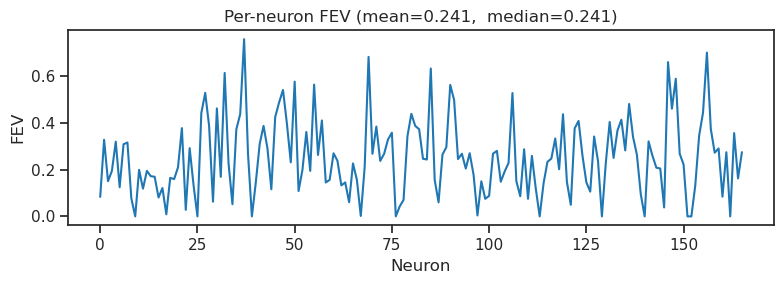

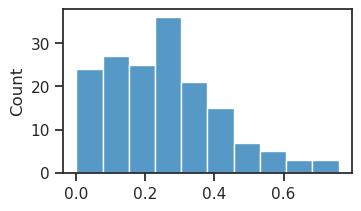

# params: 313.7 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois_ImageNet40_beta(1)_kms-(128,10,3)_recon-exact_rebuttal_imagenet40_mach-0_(2026_
03_30,13:28)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,13:28).pt

Held-out FEV mean: 0.3171502649784088

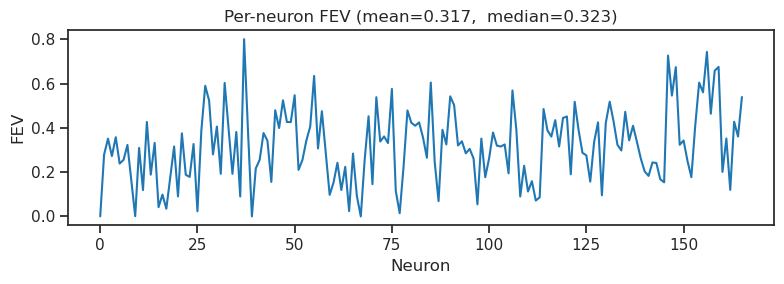

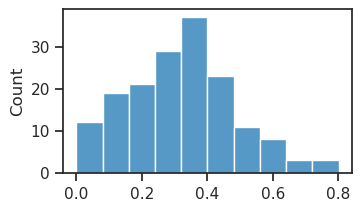

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois_ImageNet40_beta(1)_kms-(128,11,3)_recon-exact_rebuttal_imagenet40_yoru-0_(2026_
03_30,12:32)

Checkpoint File: PoissonVAE+Trainer-0030_(2026_03_30,12:32).pt

Held-out FEV mean: 0.167415589094162

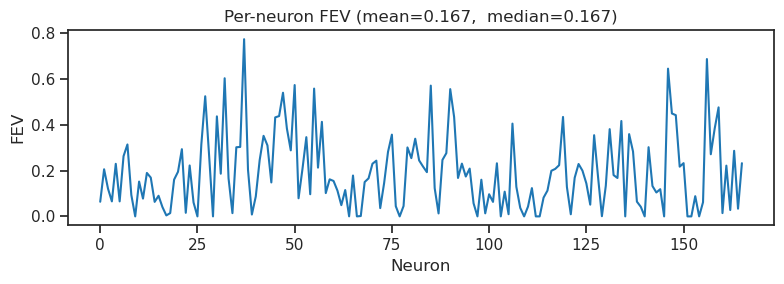

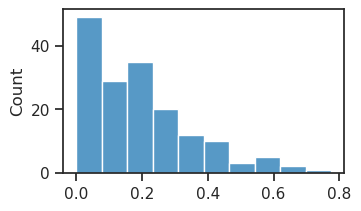

# params: 27.3 K

Successfully loaded model from 
/home/hadi/Dropbox/chkpts/MCFE/pois_ImageNet40_beta(1)_kms-(128,11,3)_recon-exact_rebuttal_imagenet40_yoru-0_(2026_
03_30,13:04)

Checkpoint File: PoissonVAE+Trainer-0060_(2026_03_30,13:04).pt

[PROGRESS] 'df_rebuttal_imagenet40.df' saved at
/home/hadi/Dropbox/git/jb-progress-2026/tmp

CPU times: user 1h 25min 18s, sys: 4min 9s, total: 1h 29min 27s
Wall time: 32min 41s


In [9]:
%%time


df = []

kws_fit = dict(model=None, batch_size=300, device=device, feature='firing-rate')


for f in fits:
    # 1. Load pretrained model
    try:
        tr, meta = load_model(target_path=pjoin(chkpts_dir, f), verbose=True)
    except RuntimeError:
        print(f"Weird run:\n{f}")
    if tr.cfg.epochs != 30:
        continue
    kws_fit['model'] = tr.model
    
    # 2. Extrtact features
    train_ds_feat = normative_modules.extract_features(dataset=train_ds_raw, **kws_fit)
    val_ds_feat = normative_modules.extract_features(dataset=val_ds_raw, **kws_fit)

    # 3. Create feature dataset
    train_dl, val_dl = normative_modules.build_dataloaders(
        train_ds_feat.to(device), val_ds_feat.to(device), batch_size=1000)
    
    # 4. Create readout model
    readout_model = normative_modules.ReadoutOnly(
        filter_dims=tr.model.cfg.latent_sz,
        num_neurons=num_neurons,
        rank=2,
    ).to(device)
    
    # 5. Create optimizer
    optimizer = torch.optim.AdamW(
        readout_model.parameters(),
        lr=1e-3,
        weight_decay=0.1,
    )
    
    # 6. Fit readout model
    best_state, train_losses, val_losses = normative_modules.fit_readout_sgd(
        readout_model, train_dl, val_dl, optimizer,
        max_epochs=1_000, patience=20, min_lr=1e-4,
        verbose=False,
    )
    readout_model.load_state_dict(best_state)
    
    # 7. Plot results
    fev_all = process_and_plot_results()
    
    # 8. Get wandb run (for ELBO)
    with open(pjoin(chkpts_dir, f, f"{f}.json"), 'r') as file:
        json_data = json.load(file)
    wandb_run = api.run(path=json_data['wandb_run_path'])

    # 8. Collect results

    if tr.model.cfg.recon_mode == 'exact':
        method = 'exact'
        temp = 0.0
    else:
        indicator = tr.model.cfg.indicator_approx
        method = f"EAT_{indicator}"
        temp = tr.cfg.temp_stop

    df.append({
        'run_id': wandb_run.id,
        'lin_enc': tr.model.cfg.lin_enc,
        'method': method,
        'temp': temp,
        'fev_mean': np.nanmean(fev_all),
        'fev_median': np.nanmedian(fev_all),
        'elbo': wandb_run.summary['eval/elbo'],
    })

df = pd.DataFrame(df)

save_obj(
    obj=df,
    file_name=f"df_{TAG}",
    save_dir=tmp_dir,
    verbose=True,
    mode='df',
)

In [10]:
df.loc[df['lin_enc']]

,run_id,lin_enc,method,temp,fev_mean,fev_median,elbo
5,ext0cwip,True,EAT_cubic,0.05,0.212841,0.192499,720.386658
6,wl7ef3d1,True,EAT_cubic,0.10,0.223422,0.201247,721.051453
7,709571dt,True,EAT_cubic,0.02,0.225734,0.202969,720.274658
8,iy8su9qg,True,EAT_cubic,0.20,0.199075,0.178528,723.006714
9,ce402po6,True,EAT_cubic,0.50,0.221782,0.207239,733.304016
15,c14ab3ch,True,EAT_sigmoid,0.05,0.237118,0.212806,758.747742
16,pfmgguts,True,EAT_sigmoid,0.20,0.240125,0.218426,755.403015
17,v8ynw452,True,EAT_sigmoid,0.10,0.236592,0.218529,757.281677
18,d5vei7uu,True,EAT_sigmoid,0.02,0.236747,0.219508,759.577515
19,ptpaz9hh,True,EAT_sigmoid,0.50,0.252528,0.241057,764.304932


In [11]:
df.loc[~df['lin_enc']]

,run_id,lin_enc,method,temp,fev_mean,fev_median,elbo
0,ymrvdw2s,False,EAT_cubic,0.50,0.334664,0.334953,580.236389
1,d799grm1,False,EAT_cubic,0.02,0.329199,0.327663,586.020569
2,9kr6s2a8,False,EAT_cubic,0.10,0.323561,0.330092,582.913208
3,dmn93gs2,False,EAT_cubic,0.05,0.327771,0.317379,583.397034
4,qpsj583x,False,EAT_cubic,0.20,0.331478,0.326026,581.316895
10,fuk51hgz,False,EAT_sigmoid,0.50,0.346946,0.340982,588.407349
11,hh45fgq4,False,EAT_sigmoid,0.20,0.336146,0.342313,585.231323
12,9alsgf28,False,EAT_sigmoid,0.10,0.326060,0.324050,585.381409
13,3ukb64o6,False,EAT_sigmoid,0.05,0.325856,0.330566,586.288452
14,o9usid83,False,EAT_sigmoid,0.02,0.327479,0.330318,588.743042


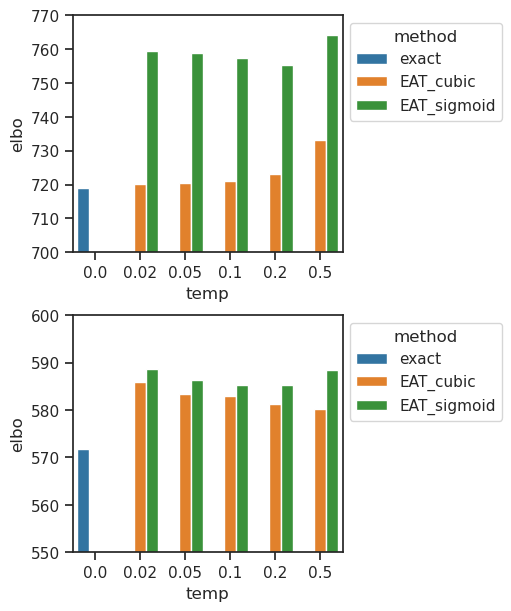

In [12]:
fig, axes = create_figure(2, 1, (5, 6))

sns.barplot(data=df.loc[df['lin_enc']], x='temp', y='elbo', hue='method', ax=axes[0])
sns.barplot(data=df.loc[~df['lin_enc']], x='temp', y='elbo', hue='method', ax=axes[1])

axes[0].set_ylim(700, 770)
axes[1].set_ylim(550, 600)

move_legend(axes[0], (1, 1))
move_legend(axes[1], (1, 1))
plt.show()

## small_data_regime

In [14]:
api = wandb.Api()

TAG = 'small_data_regime'

wandb_runs = api.runs(path='pal-lab/MCFE', filters={"tags": TAG})

In [25]:
df2 = []

for run in wandb_runs:
    if run.config['recon_mode'] == 'exact':
        method = 'exact'
        temp = 0.0
    else:
        method = f"EAT_{run.config['indicator_approx']}"
        temp = run.config['temp_stop']
    
    elbo = run.summary['eval/elbo']
    
    if temp > 0.0:
        elbo += 1.2
        
    df2.append({
        'run_id': run.id,
        'method': method,
        'temp': temp,
        'elbo': elbo,
    })
    
df2 = pd.DataFrame(df2)

In [26]:
df2

,run_id,method,temp,elbo
0,5sx5wzym,EAT_cubic,0.05,170.108707
1,pbjuvk4v,EAT_cubic,0.50,171.169803
2,b53wk1y7,EAT_sigmoid,0.50,180.500659
3,kn54kxg4,EAT_sigmoid,0.05,170.064044
4,iqqvhgzt,exact,0.00,182.685303
